In [1]:
from typing import TypedDict, Literal

from langchain_core.runnables import RunnableConfig
from langgraph.managed import  RemainingSteps
from loguru import  logger
from langgraph.graph import StateGraph,START,END

# 1. 声明状态
class OverAllState(TypedDict):
    remaining_steps:RemainingSteps

# 2. 声明循环节点
def loop_node(state:OverAllState,config:RunnableConfig) -> OverAllState:
    cur_step = config["metadata"]["langgraph_step"]
    remaining_steps = state["remaining_steps"]
    logger.info("loop_node,cur_step:{},remaining_step:{}",cur_step,remaining_steps)

#3. 添加路由
def router(state:OverAllState) -> Literal["loop_node",END]:
    remaining_steps = state["remaining_steps"]
    if remaining_steps < 3:
        logger.info("当前可用超步:{},已经不足3步,终止循环",remaining_steps)
        return END
    return "loop_node"

#4. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("loop_node",loop_node)
builder.add_edge(START,"loop_node")
builder.add_conditional_edges("loop_node",router)

graph = builder.compile()
graph.invoke({},config={"recursion_limit": 10})


2026-08-12 21:50:20.214 | INFO     | __main__:loop_node:16 - loop_node,cur_step:1,remaining_step:9
2026-08-12 21:50:20.215 | INFO     | __main__:loop_node:16 - loop_node,cur_step:2,remaining_step:8
2026-08-12 21:50:20.215 | INFO     | __main__:loop_node:16 - loop_node,cur_step:3,remaining_step:7
2026-08-12 21:50:20.216 | INFO     | __main__:loop_node:16 - loop_node,cur_step:4,remaining_step:6
2026-08-12 21:50:20.216 | INFO     | __main__:loop_node:16 - loop_node,cur_step:5,remaining_step:5
2026-08-12 21:50:20.216 | INFO     | __main__:loop_node:16 - loop_node,cur_step:6,remaining_step:4
2026-08-12 21:50:20.217 | INFO     | __main__:loop_node:16 - loop_node,cur_step:7,remaining_step:3
2026-08-12 21:50:20.217 | INFO     | __main__:loop_node:16 - loop_node,cur_step:8,remaining_step:2
2026-08-12 21:50:20.218 | INFO     | __main__:router:22 - 当前可用超步:2,已经不足3步,终止循环


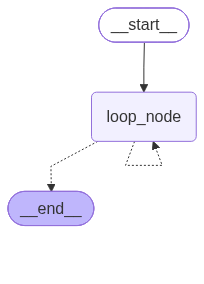

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	loop_node(loop_node)
	__end__([<p>__end__</p>]):::last
	__start__ --> loop_node;
	loop_node -.-> __end__;
	loop_node -.-> loop_node;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [2]:
from IPython.display import display
display(graph)

raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)